# Filter FTW Catalog by Country Boundary Intersection

Identify samples in the FTW catalog without fields.  There are two kinds we are interested in:

1. Those with 0 fields that are outside of country boundaries, which may represent false negatives (see Austria); 
2. Those contained within country boundaries that have 0 fields. These may represent either false or true negatives.  Signs of spatial patterns in non-field labels (NFLs) are potential indicator of false negatives (e.g. a row or rows of adjacent NFLs). 

We search for these using point centroids from our catalog of the FTW dataset, which included proportion of the pixel covered by labeled fields.  

**Note**: Since we are dealing with centroids, a number of valid labels that intersect the country will be captured, which means they could be true negatives with respect to that country. 

**Filter rule:** `~in_country AND (fld_prop == 0)`

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import Point

## Load Catalog


Set `CATALOG_PATH` and `ZERO_COV_THRESHOLD` (minimum proportion of NFLs within a country for it be selected for plotting).

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
CATALOG_PATH = "../data/ftw-catalog.csv"   # switch to ftw-catalog2.csv as needed

# Countries whose in-boundary points have > this fraction of fld_prop==0
# will get a zoom plot in the "High Zero-Coverage" section below.
ZERO_COV_THRESHOLD = 0.05  # 10%

# Load selected catalog
cat = pd.read_csv(CATALOG_PATH)
print(f"{CATALOG_PATH}: {len(cat):,} rows")
print(f"  countries: {sorted(cat['country'].str.lower().unique())}")
print(f"  fld_prop==0 rows: {(cat['fld_prop'] == 0).sum():,}")
cat.head(2)

../data/ftw-catalog.csv: 70,484 rows
  countries: ['austria', 'belgium', 'brazil', 'cambodia', 'corsica', 'croatia', 'denmark', 'estonia', 'finland', 'france', 'germany', 'india', 'kenya', 'latvia', 'lithuania', 'luxembourg', 'netherlands', 'portugal', 'rwanda', 'slovakia', 'slovenia', 'south_africa', 'spain', 'sweden', 'vietnam']
  fld_prop==0 rows: 10,827


,name,dataset,version,country,x,y,fld_prop,nonfld_prop,null_prop,window_a,window_b,mask,split
0,g0_0000002048-0000010240,ftw,1.0.0,kenya,34.573119,0.600720,0.000519,0.0,0.999481,ftw/kenya/s2_images/window_a/g0_0000002048-000...,ftw/kenya/s2_images/window_b/g0_0000002048-000...,ftw/kenya/label_masks/semantic_3class/g0_00000...,test
1,g0_0000001024-0000010752,ftw,1.0.0,kenya,34.586902,0.628378,0.000061,0.0,0.999939,ftw/kenya/s2_images/window_a/g0_0000001024-000...,ftw/kenya/s2_images/window_b/g0_0000001024-000...,ftw/kenya/label_masks/semantic_3class/g0_00000...,train


**Convert to GeoDataFrame**

Each row's `(x, y)` pair is the center point of the chip in WGS-84 (EPSG:4326).

In [3]:
gdf = gpd.GeoDataFrame(
    cat.copy(), 
    geometry=gpd.GeoSeries.from_xy(cat["x"], cat["y"], crs="EPSG:4326")
)
print(f"gdf CRS: {gdf.crs}  |  shape: {gdf.shape}")

gdf CRS: EPSG:4326  |  shape: (70484, 14)


## Load Country Boundaries

Uses Natural Earth **10m** (high-resolution) country polygons for accurate coastal and island boundaries.

In [4]:
# Load Natural Earth 10m country polygons (high-resolution — accurate for islands/coastlines)
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/"
    "ne_10m_admin_0_countries.zip"
)
world = world[["ADMIN", "geometry"]]
world.rename(columns={"ADMIN": "name"}, inplace=True)

print(f"Natural Earth: {len(world)} countries | CRS: {world.crs}")
print(f"Columns: {list(world.columns)}")

# Mapping from catalog lowercase country name → Natural Earth 'name' field
NAME_MAP: dict[str, str] = {
    "austria":      "Austria",
    "belgium":      "Belgium",
    "brazil":       "Brazil",
    "cambodia":     "Cambodia",
    "corsica":      "France",
    "denmark":      "Denmark",
    "estonia":      "Estonia",
    "ethiopia":     "Ethiopia",
    "finland":      "Finland",
    "france":       "France",
    "germany":      "Germany",
    "india":        "India",
    "kenya":        "Kenya",
    "latvia":       "Latvia",
    "lithuania":    "Lithuania",
    "luxembourg":   "Luxembourg",
    "netherlands":  "Netherlands",
    "portugal":     "Portugal",
    "south_africa": "South Africa",
    "spain":        "Spain",
    "sweden":       "Sweden",
    "united states of america": "United States of America",
    "united states":            "United States of America",
    "usa":                      "United States of America",
}

# Report any catalog countries absent from the NE dataset
catalog_countries = set(cat["country"].str.lower().unique())
ne_names = set(world["name"].unique())
for c in sorted(catalog_countries):
    ne_name = NAME_MAP.get(c, c.title())
    status = "OK" if ne_name in ne_names else "MISSING"
    print(f"  {status}  catalog='{c}' -> NE='{ne_name}'")

Natural Earth: 258 countries | CRS: EPSG:4326
Columns: ['name', 'geometry']
  OK  catalog='austria' -> NE='Austria'
  OK  catalog='belgium' -> NE='Belgium'
  OK  catalog='brazil' -> NE='Brazil'
  OK  catalog='cambodia' -> NE='Cambodia'
  OK  catalog='corsica' -> NE='France'
  OK  catalog='croatia' -> NE='Croatia'
  OK  catalog='denmark' -> NE='Denmark'
  OK  catalog='estonia' -> NE='Estonia'
  OK  catalog='finland' -> NE='Finland'
  OK  catalog='france' -> NE='France'
  OK  catalog='germany' -> NE='Germany'
  OK  catalog='india' -> NE='India'
  OK  catalog='kenya' -> NE='Kenya'
  OK  catalog='latvia' -> NE='Latvia'
  OK  catalog='lithuania' -> NE='Lithuania'
  OK  catalog='luxembourg' -> NE='Luxembourg'
  OK  catalog='netherlands' -> NE='Netherlands'
  OK  catalog='portugal' -> NE='Portugal'
  OK  catalog='rwanda' -> NE='Rwanda'
  OK  catalog='slovakia' -> NE='Slovakia'
  OK  catalog='slovenia' -> NE='Slovenia'
  OK  catalog='south_africa' -> NE='South Africa'
  OK  catalog='spain' -> 

## Check Spatial Containment

For each sample, test whether its center point lies within the Natural Earth polygon of the country it is labeled with.

Uses vectorised `geopandas` `.within()` — one pass per unique country.

In [5]:
def add_in_country(gdf: gpd.GeoDataFrame, world: gpd.GeoDataFrame,
                   name_map: dict) -> gpd.GeoDataFrame:
    """
    Add `in_country`, `outside`, and `filter_target` columns.
    `in_country` is True if the point lies within the NE polygon for the labeled
    country. Unmatched country names get NaN (treated as outside).
    """
    gdf = gdf.copy()
    gdf["country_ne"] = gdf["country"].str.lower().map(
        lambda c: name_map.get(c, c.title())
    )
    gdf["in_country"] = None

    for ne_name, group in gdf.groupby("country_ne"):
        country_rows = world[world["name"] == ne_name]
        if country_rows.empty:
            print(f"  WARNING: '{ne_name}' not found in Natural Earth; skipping")
            continue
        try:
            poly = country_rows.geometry.union_all()
        except AttributeError:  # geopandas < 0.14 / shapely < 2.0
            poly = country_rows.geometry.unary_union
        gdf.loc[group.index, "in_country"] = group.geometry.within(poly)

    gdf["in_country"] = gdf["in_country"].astype("boolean")
    gdf["outside"] = ~gdf["in_country"].fillna(False)
    gdf["filter_target"] = gdf["outside"] & (gdf["fld_prop"] == 0)
    return gdf


print(f"Running containment check for {CATALOG_PATH} ...")
gdf = add_in_country(gdf, world, NAME_MAP)

n_out  = gdf["outside"].sum()
n_null = gdf["in_country"].isna().sum()
print(f"  in-country:  {gdf['in_country'].sum():,}")
print(f"  outside:     {n_out:,}  (includes {n_null} with unmatched country name)")

Running containment check for ../data/ftw-catalog.csv ...
  in-country:  69,431
  outside:     1,053  (includes 0 with unmatched country name)


## Per-Country Breakdown

For each country: total samples, samples outside boundary, and samples that hit **both** filter criteria (outside boundary AND `fld_prop == 0`).

In [6]:
def country_breakdown(gdf: gpd.GeoDataFrame, label: str) -> pd.DataFrame:
    """Return a per-country summary of containment and zero-coverage flags."""
    summary = (
        gdf.groupby("country")
        .agg(
            total=("name", "count"),
            outside_boundary=("outside", "sum"),
            fld_prop_zero=("fld_prop", lambda s: (s == 0).sum()),
            filter_target=("filter_target", "sum"),
        )
        .sort_values("filter_target", ascending=False)
        .astype(int)
    )
    summary.index.name = "country"
    print(f"\n=== {label} ===")
    return summary


summary = country_breakdown(gdf, CATALOG_PATH)
display(summary)


=== ../data/ftw-catalog.csv ===


,total,outside_boundary,fld_prop_zero,filter_target
country,,,,
austria,6685,919,1231,845
corsica,2472,91,1714,76
denmark,3560,34,61,8
croatia,3482,4,410,2
portugal,66,4,6,1
lithuania,5258,0,661,0
sweden,4760,0,556,0
spain,2432,0,133,0
south_africa,747,0,35,0


## Filter Mask

Rows to remove: outside their labeled country boundary **AND** `fld_prop == 0`.

`dropped_rows` and `kept_rows` are output as DataFrames with the original catalog schema.

In [7]:
_orig_cols = list(cat.columns)

drop_mask    = gdf["filter_target"]
dropped_rows = gdf.loc[drop_mask,  _orig_cols].reset_index(drop=True)
kept_rows    = gdf.loc[~drop_mask, _orig_cols].reset_index(drop=True)

print(f"{CATALOG_PATH}:")
print(f"  Total rows:   {len(gdf):,}")
print(f"  Rows to drop: {drop_mask.sum():,}  ({drop_mask.mean()*100:.2f}%)")
print(f"  Rows to keep: {(~drop_mask).sum():,}")
print(f"\ndropped_rows  ({len(dropped_rows)} rows):")
display(dropped_rows)

../data/ftw-catalog.csv:
  Total rows:   70,484
  Rows to drop: 932  (1.32%)
  Rows to keep: 69,552

dropped_rows  (932 rows):


,name,dataset,version,country,x,y,fld_prop,nonfld_prop,null_prop,window_a,window_b,mask,split
0,g10-3_00004_8,ftw,1.0.0,croatia,17.108406,46.138873,0.0,1.0,0.0,ftw/croatia/s2_images/window_a/g10-3_00004_8.tif,ftw/croatia/s2_images/window_b/g10-3_00004_8.tif,ftw/croatia/label_masks/semantic_3class/g10-3_...,train
1,g10-3_00004_9,ftw,1.0.0,croatia,17.122235,46.138873,0.0,1.0,0.0,ftw/croatia/s2_images/window_a/g10-3_00004_9.tif,ftw/croatia/s2_images/window_b/g10-3_00004_9.tif,ftw/croatia/label_masks/semantic_3class/g10-3_...,train
2,g22_0000000000-0000001536,ftw,1.0.0,portugal,-31.098077,39.727077,0.0,1.0,0.0,ftw/portugal/s2_images/window_a/g22_0000000000...,ftw/portugal/s2_images/window_b/g22_0000000000...,ftw/portugal/label_masks/semantic_3class/g22_0...,test
3,g3_00007_12,ftw,1.0.0,corsica,9.499225,42.056985,0.0,1.0,0.0,ftw/corsica/s2_images/window_a/g3_00007_12.tif,ftw/corsica/s2_images/window_b/g3_00007_12.tif,ftw/corsica/label_masks/semantic_3class/g3_000...,train
4,g3_00007_13,ftw,1.0.0,corsica,9.513054,42.056985,0.0,1.0,0.0,ftw/corsica/s2_images/window_a/g3_00007_13.tif,ftw/corsica/s2_images/window_b/g3_00007_13.tif,ftw/corsica/label_masks/semantic_3class/g3_000...,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,g95_00023_0,ftw,1.0.0,austria,15.930975,48.819951,0.0,1.0,0.0,ftw/austria/s2_images/window_a/g95_00023_0.tif,ftw/austria/s2_images/window_b/g95_00023_0.tif,ftw/austria/label_masks/semantic_3class/g95_00...,test
928,g95_00023_1,ftw,1.0.0,austria,15.944759,48.819951,0.0,1.0,0.0,ftw/austria/s2_images/window_a/g95_00023_1.tif,ftw/austria/s2_images/window_b/g95_00023_1.tif,ftw/austria/label_masks/semantic_3class/g95_00...,test
929,g95_00023_2,ftw,1.0.0,austria,15.958543,48.819951,0.0,1.0,0.0,ftw/austria/s2_images/window_a/g95_00023_2.tif,ftw/austria/s2_images/window_b/g95_00023_2.tif,ftw/austria/label_masks/semantic_3class/g95_00...,test
930,g95_00025_3,ftw,1.0.0,austria,15.944759,48.806167,0.0,1.0,0.0,ftw/austria/s2_images/window_a/g95_00025_3.tif,ftw/austria/s2_images/window_b/g95_00025_3.tif,ftw/austria/label_masks/semantic_3class/g95_00...,train


## World Overview Map

All sample center points coloured by containment status:
- **Blue** — point is within its labeled country boundary
- **Orange** — point is outside country but has fields (keep)
- **Red** — point is outside country boundary **and** has no fields (drop)

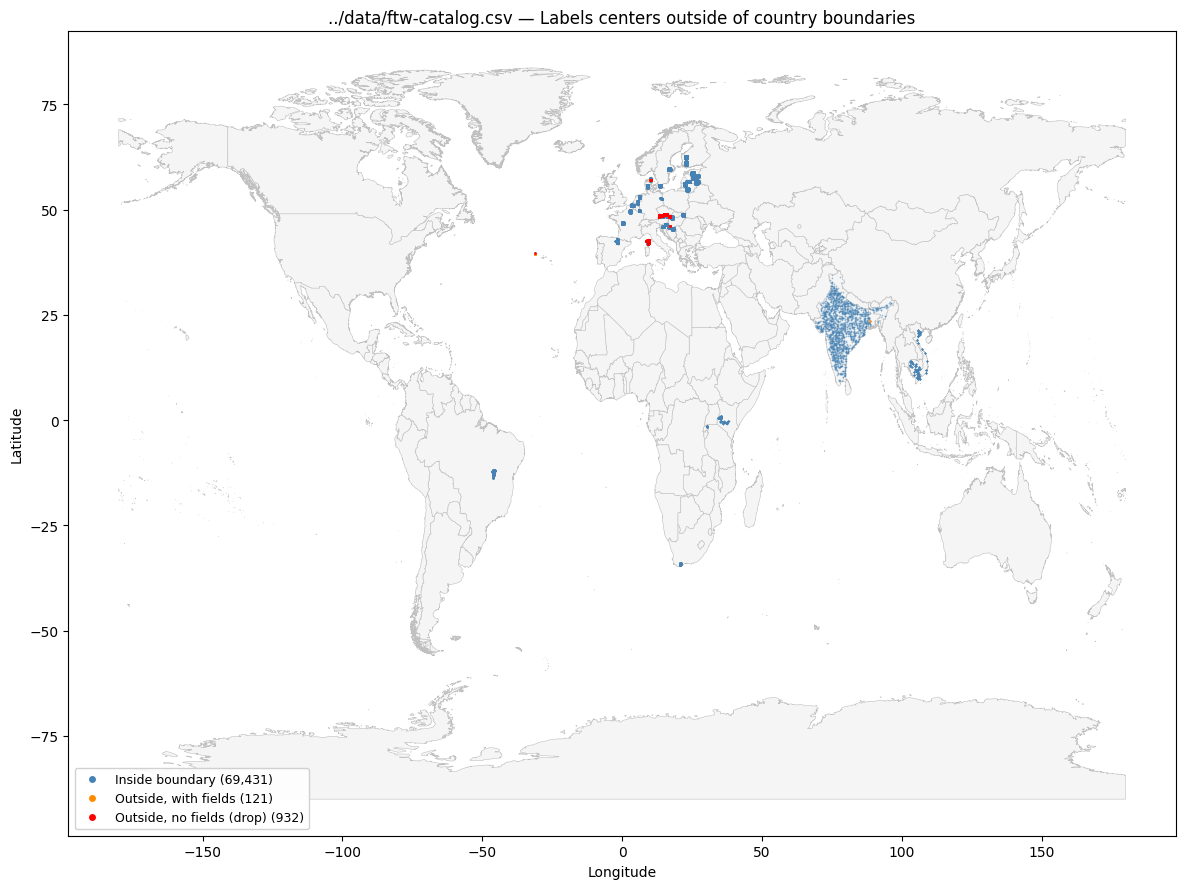

In [8]:
fig, ax = plt.subplots(figsize=(16, 9))

world.plot(ax=ax, color="whitesmoke", edgecolor="silver", linewidth=0.4)

in_      = gdf[~gdf["outside"]]
out_keep = gdf[gdf["outside"] & (gdf["fld_prop"] > 0)]
out_drop = gdf[gdf["filter_target"]]

plot_kw = dict(markersize=1.5, linewidth=0, alpha=0.5)
in_.plot(ax=ax, color="steelblue", **plot_kw)
out_keep.plot(ax=ax, color="darkorange", markersize=4, linewidth=0, alpha=0.8)
out_drop.plot(ax=ax, color="red", markersize=4, linewidth=0, alpha=0.9)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=6, label=f"Inside boundary ({len(in_):,})"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange",
           markersize=6, label=f"Outside, with fields ({len(out_keep):,})"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
           markersize=6, label=f"Outside, no fields (drop) ({len(out_drop):,})"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"{CATALOG_PATH} — Labels centers outside of country boundaries", 
             fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Country-Level Plots

One plot per country that has at least one filter-target sample
(outside boundary AND no fields).  

Note, for countries besides Austria, many of these out of bounds samples are likely valid negative chips along the coastline. They are a relatively small number, so filtering them out probably does little to harm the model, although might marginally reduce robustness to mistakes over water bodies. 

Countries with filter-target samples: ['austria', 'corsica', 'croatia', 'denmark', 'portugal']


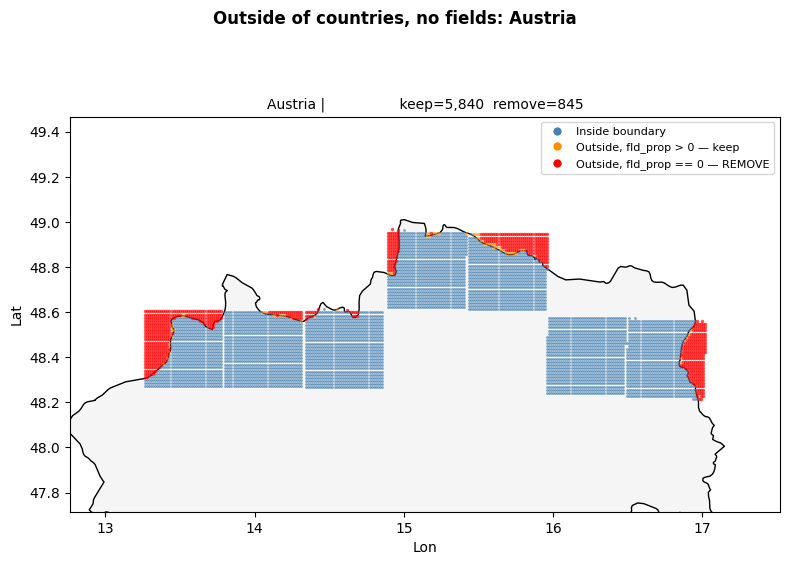

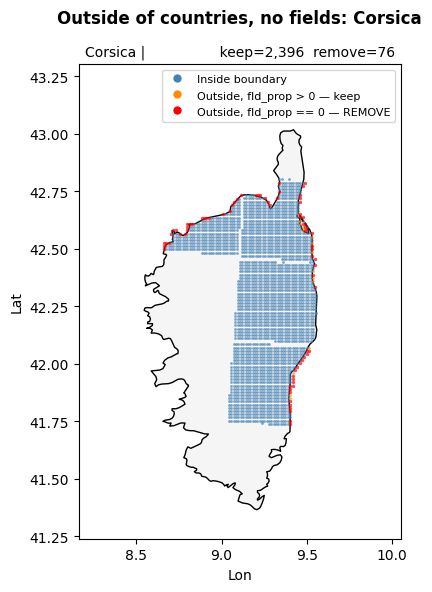

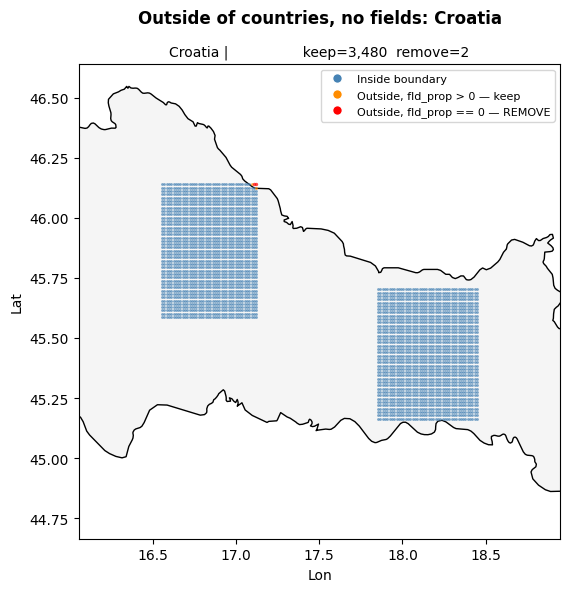

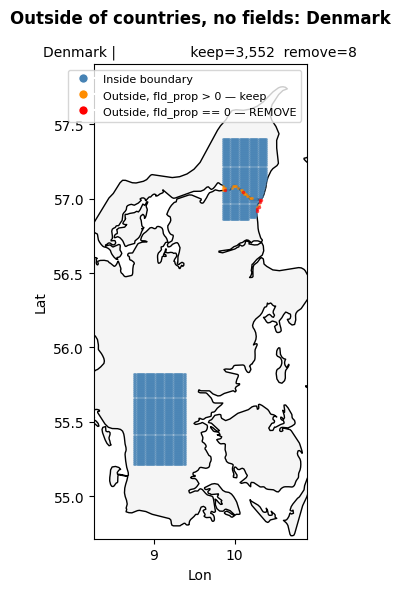

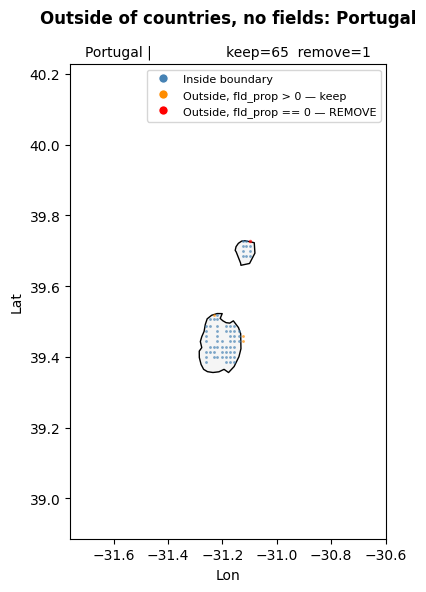

In [9]:
problem_countries = sorted(gdf.loc[gdf["filter_target"], "country"].unique())
print(f"Countries with filter-target samples: {problem_countries}")

_legend_misplaced = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=7, label="Inside boundary"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange",
           markersize=7, label="Outside, fld_prop > 0 — keep"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
           markersize=7, label="Outside, fld_prop == 0 — REMOVE"),
]

for country in problem_countries:
    ne_name = NAME_MAP.get(country.lower(), country.title())
    country_poly = world[world["name"] == ne_name]
    sub = gdf[gdf["country"].str.lower() == country.lower()]

    in_      = sub[~sub["outside"]]
    out_keep = sub[sub["outside"] & (sub["fld_prop"] > 0)]
    out_drop = sub[sub["filter_target"]]

    fig, ax = plt.subplots(figsize=(8, 6))
    if not country_poly.empty:
        country_poly.plot(ax=ax, facecolor="whitesmoke", edgecolor="black", 
                          linewidth=1.0)

    kw = dict(linewidth=0, alpha=0.7)
    if len(in_):      in_.plot(ax=ax, color="steelblue", markersize=4, **kw)
    if len(out_keep): out_keep.plot(ax=ax, color="darkorange", markersize=4, **kw)
    if len(out_drop): out_drop.plot(ax=ax, color="red", markersize=6, **kw)

    if len(sub):
        minx, miny, maxx, maxy = sub.total_bounds
        buf_x = max((maxx - minx) * 0.10, 0.5)
        buf_y = max((maxy - miny) * 0.10, 0.5)
        ax.set_xlim(minx - buf_x, maxx + buf_x)
        ax.set_ylim(miny - buf_y, maxy + buf_y)

    ax.legend(handles=_legend_misplaced, fontsize=8, loc="best")
    ax.set_title(f"{country.title()} |\
                 keep={len(in_)+len(out_keep):,}  remove={len(out_drop):,}",
                 fontsize=10)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    fig.suptitle(f"Outside of countries, no fields: {country.title()}", 
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Filtered Catalog

`kept_rows` and `dropped_rows` are DataFrames with the original column schema. 

We save a new catalog for ftw, with the `-fn-filtered.csv` suffix to indicate likely false negatives dropped. We also save out the false negative rows to a separate catalog. 

In [10]:
print(f"{CATALOG_PATH}  →  filtered")
print(f"  Before: {len(cat):,}   After: {len(kept_rows):,}   Removed: {len(dropped_rows):,}")
display(kept_rows.head(3))

FILTERED_CATALOG_PATH = "../data/ftw-catalog-fn-filtered.csv"
DROPPED_CATALOG_PATH = "../data/ftw-catalog-fns.csv"
dropped_rows

kept_rows.to_csv(FILTERED_CATALOG_PATH, index=False)
dropped_rows.to_csv(DROPPED_CATALOG_PATH, index=False)

../data/ftw-catalog.csv  →  filtered
  Before: 70,484   After: 69,552   Removed: 932


,name,dataset,version,country,x,y,fld_prop,nonfld_prop,null_prop,window_a,window_b,mask,split
0,g0_0000002048-0000010240,ftw,1.0.0,kenya,34.573119,0.600720,0.000519,0.0,0.999481,ftw/kenya/s2_images/window_a/g0_0000002048-000...,ftw/kenya/s2_images/window_b/g0_0000002048-000...,ftw/kenya/label_masks/semantic_3class/g0_00000...,test
1,g0_0000001024-0000010752,ftw,1.0.0,kenya,34.586902,0.628378,0.000061,0.0,0.999939,ftw/kenya/s2_images/window_a/g0_0000001024-000...,ftw/kenya/s2_images/window_b/g0_0000001024-000...,ftw/kenya/label_masks/semantic_3class/g0_00000...,train
2,g0_0000001024-0000010240,ftw,1.0.0,kenya,34.573119,0.628378,0.001083,0.0,0.998917,ftw/kenya/s2_images/window_a/g0_0000001024-000...,ftw/kenya/s2_images/window_b/g0_0000001024-000...,ftw/kenya/label_masks/semantic_3class/g0_00000...,train


## High Zero-Coverage Countries (In-Boundary)

Per-country rate of `fld_prop == 0` among samples that **correctly fall within** their labeled country boundary. Countries exceeding `ZERO_COV_THRESHOLD` get a zoom plot.
- **Blue** — `fld_prop > 0`
- **Orange** — `fld_prop == 0`

,n_in_boundary,n_zero_fld,pct_zero
country,,,
corsica,2381,1638,68.8%
estonia,6713,2014,30.0%
latvia,6938,1359,19.6%
finland,5665,1004,17.7%
slovenia,2177,357,16.4%
germany,686,103,15.0%
lithuania,5258,661,12.6%
netherlands,3879,461,11.9%
croatia,3478,408,11.7%



Countries above 5% in-boundary zero-coverage: ['corsica', 'estonia', 'latvia', 'finland', 'slovenia', 'germany', 'lithuania', 'netherlands', 'croatia', 'sweden', 'slovakia', 'portugal', 'austria', 'france', 'spain']


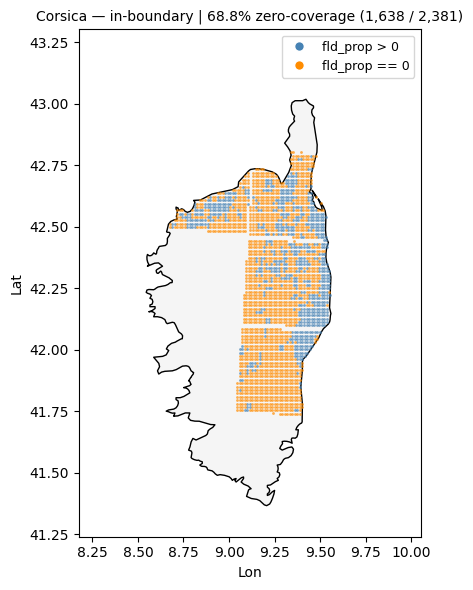

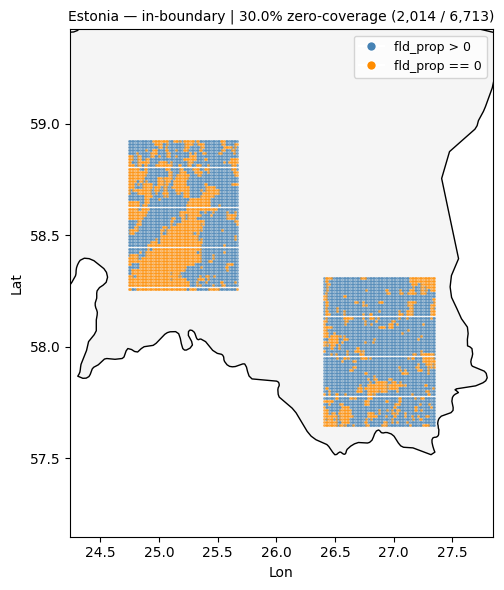

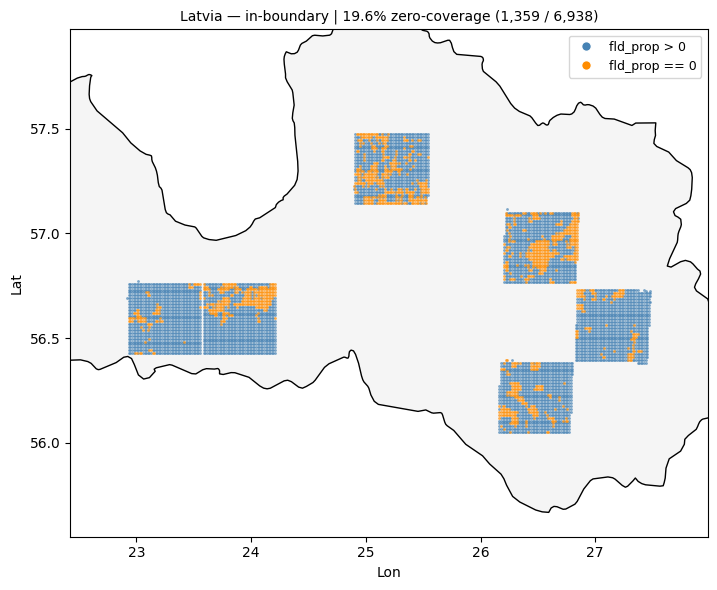

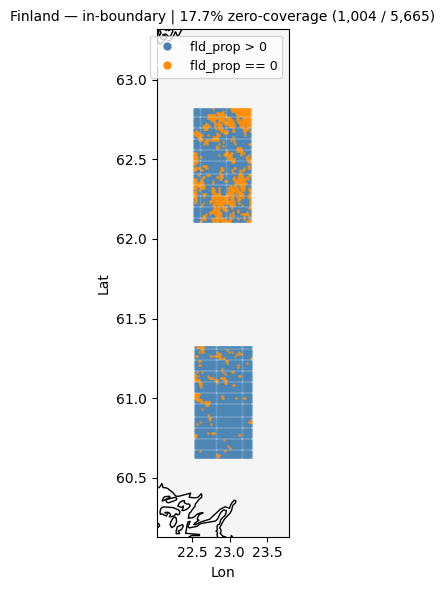

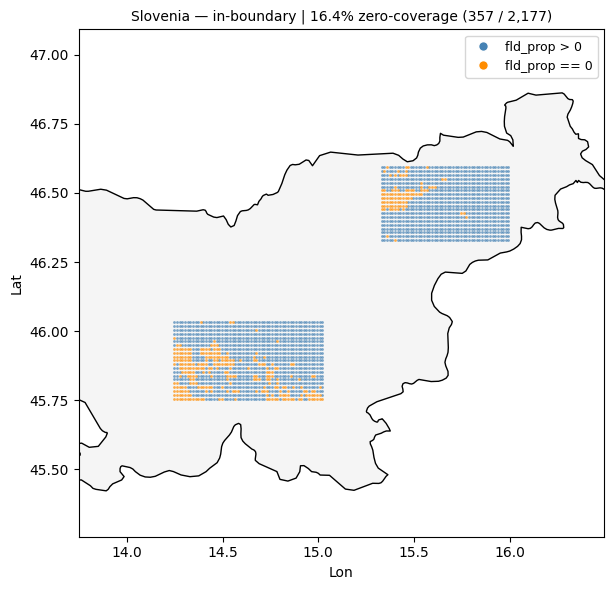

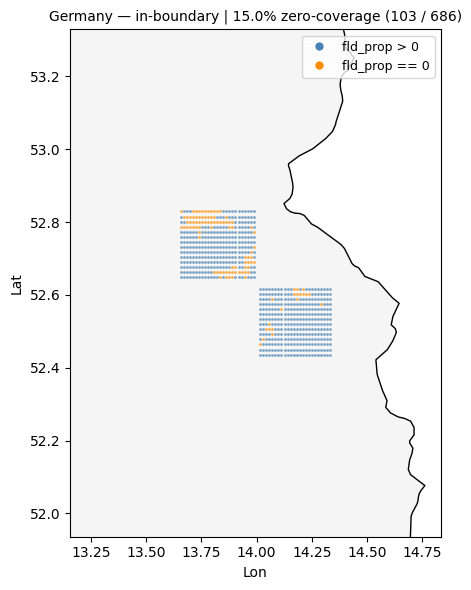

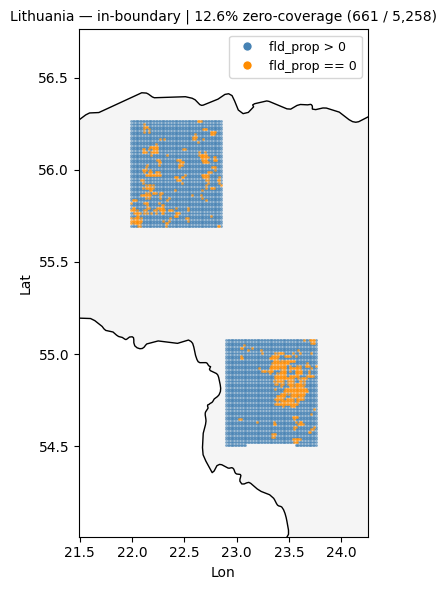

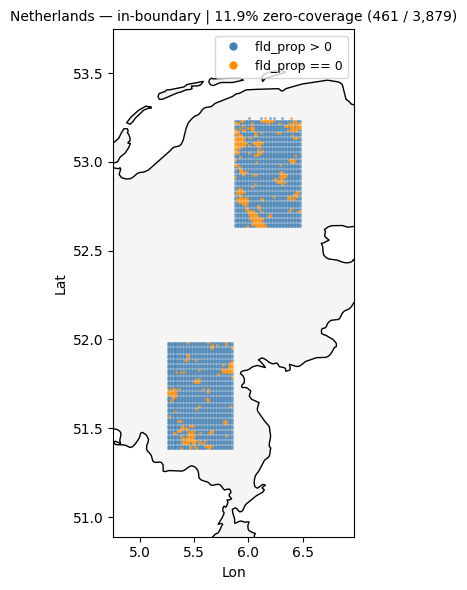

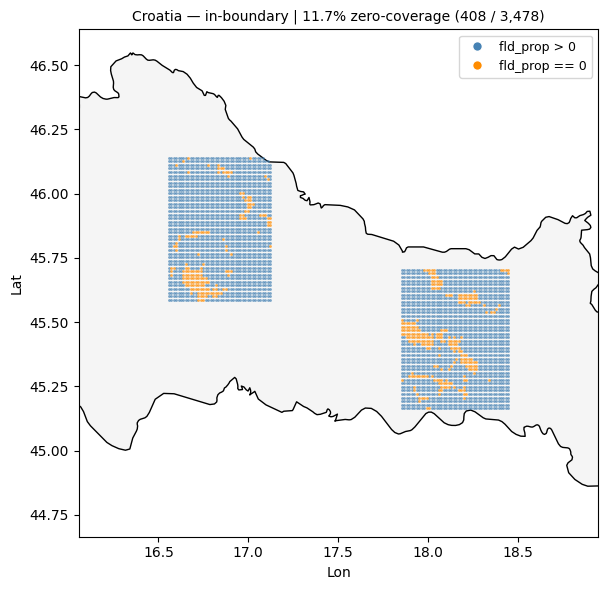

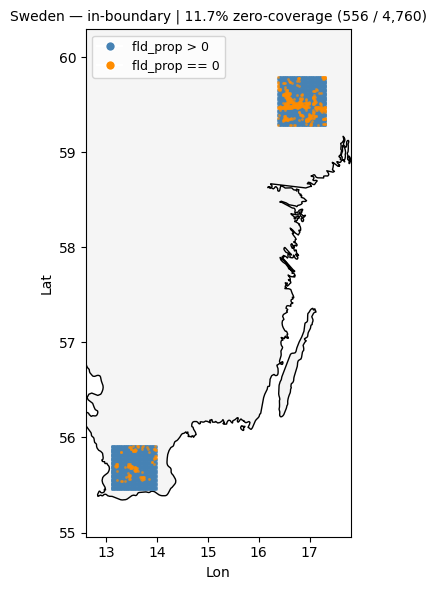

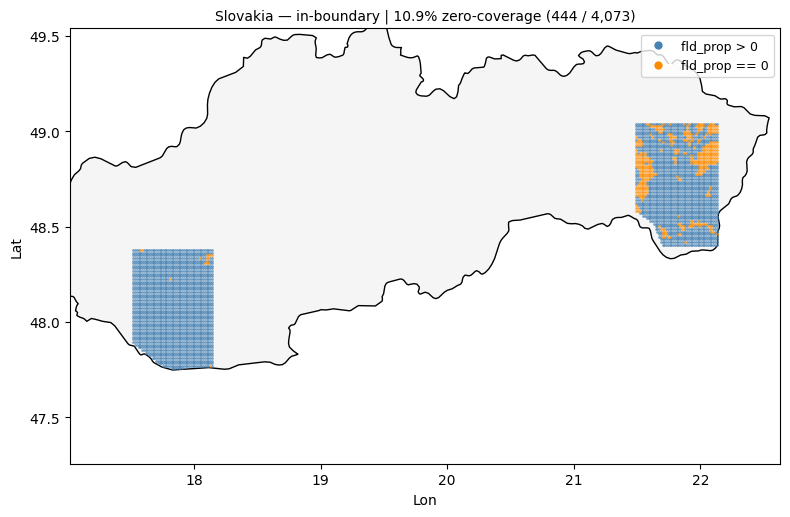

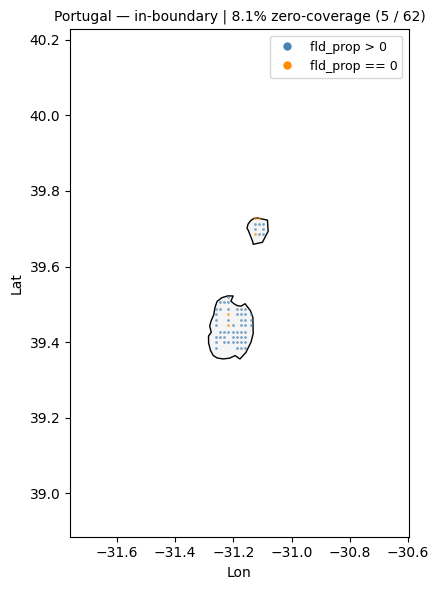

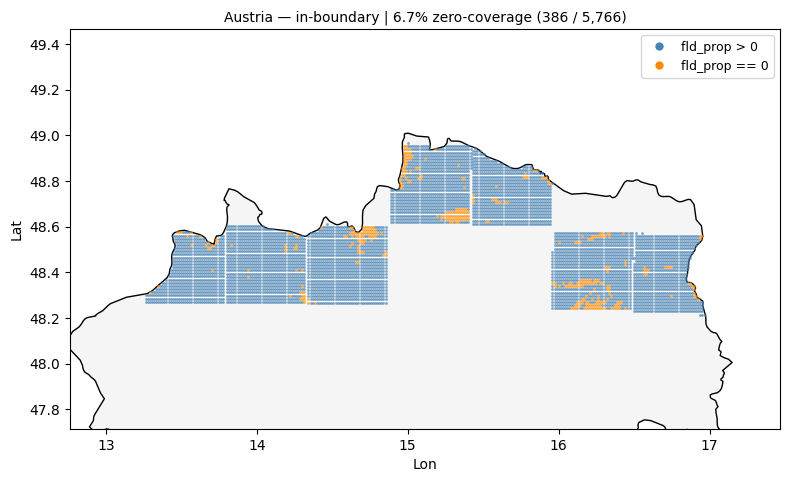

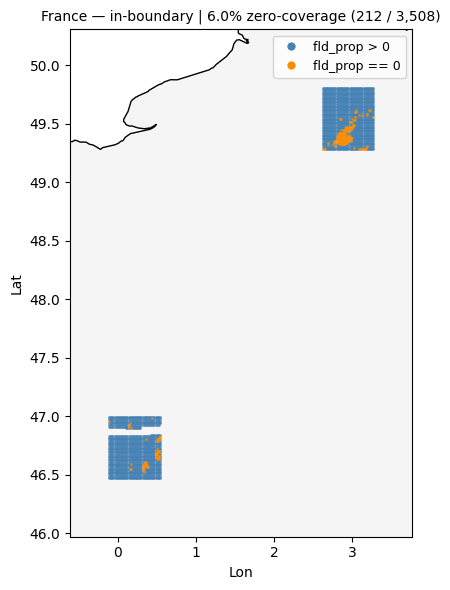

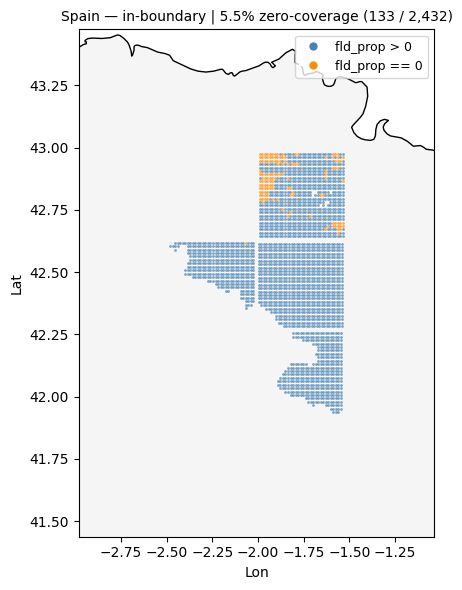

In [11]:
# Compute in-boundary zero-coverage rates per country
in_boundary = gdf[gdf["in_country"] == True].copy()

zero_cov_stats = (
    in_boundary.groupby("country")
    .agg(
        n_in_boundary=("name", "count"),
        n_zero_fld=("fld_prop", lambda s: (s == 0).sum()),
    )
)
zero_cov_stats["pct_zero"] = (
    zero_cov_stats["n_zero_fld"] / zero_cov_stats["n_in_boundary"]
)
zero_cov_stats = zero_cov_stats.sort_values("pct_zero", ascending=False)
display(zero_cov_stats.style.format({"pct_zero": "{:.1%}"}))

high_zero = zero_cov_stats[zero_cov_stats["pct_zero"] > ZERO_COV_THRESHOLD]
print(f"\nCountries above {ZERO_COV_THRESHOLD:.0%} in-boundary zero-coverage: "
      f"{list(high_zero.index)}")

_legend_zerocov = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=7, label="fld_prop > 0"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange",
           markersize=7, label="fld_prop == 0"),
]

for country in high_zero.index:
    ne_name = NAME_MAP.get(country.lower(), country.title())
    country_poly = world[world["name"] == ne_name]
    sub = in_boundary[in_boundary["country"].str.lower() == country.lower()]

    non_zero = sub[sub["fld_prop"] > 0]
    zero = sub[sub["fld_prop"] == 0]
    pct = high_zero.loc[country, "pct_zero"]

    fig, ax = plt.subplots(figsize=(8, 6))
    if not country_poly.empty:
        country_poly.plot(ax=ax, facecolor="whitesmoke", edgecolor="black", 
                          linewidth=1.0)

    kw = dict(markersize=4, linewidth=0, alpha=0.7)
    if len(non_zero): non_zero.plot(ax=ax, color="steelblue", **kw)
    if len(zero): zero.plot(ax=ax, color="darkorange", **kw)

    if len(sub):
        minx, miny, maxx, maxy = sub.total_bounds
        buf_x = max((maxx - minx) * 0.10, 0.5)
        buf_y = max((maxy - miny) * 0.10, 0.5)
        ax.set_xlim(minx - buf_x, maxx + buf_x)
        ax.set_ylim(miny - buf_y, maxy + buf_y)

    ax.legend(handles=_legend_zerocov, fontsize=9)
    ax.set_title(
        f"{country.title()} — in-boundary | {pct:.1%} zero-coverage "
        f"({len(zero):,} / {len(sub):,})",
        fontsize=10,
    )
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.tight_layout()
    plt.show()

## Spot-Check: Inspect Dropped Samples

Randomly sample rows from `dropped_rows` and display one image window alongside its label mask to verify they are genuinely zero-field chips.

Set `DATA_DIR` to the root directory that contains the relative paths stored in the `window_a`/`mask` columns.  Switch `WINDOW` to `"window_b"` to view the second time point instead.

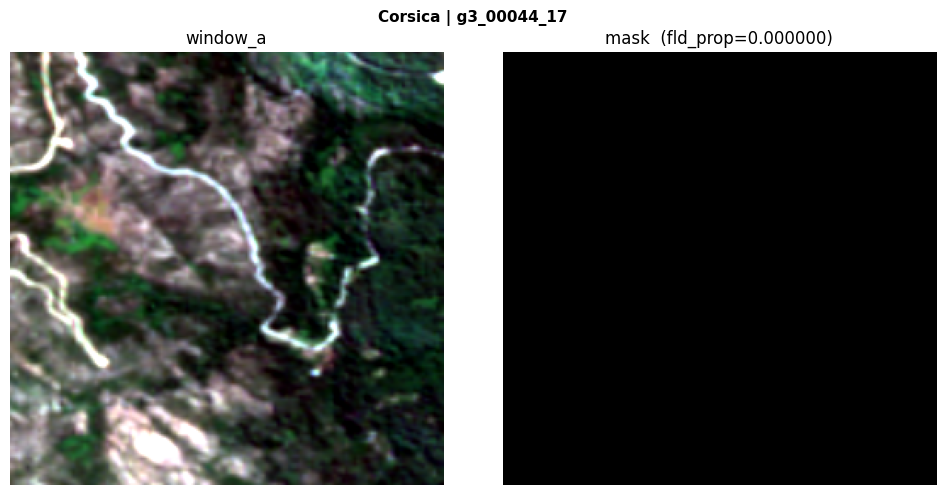

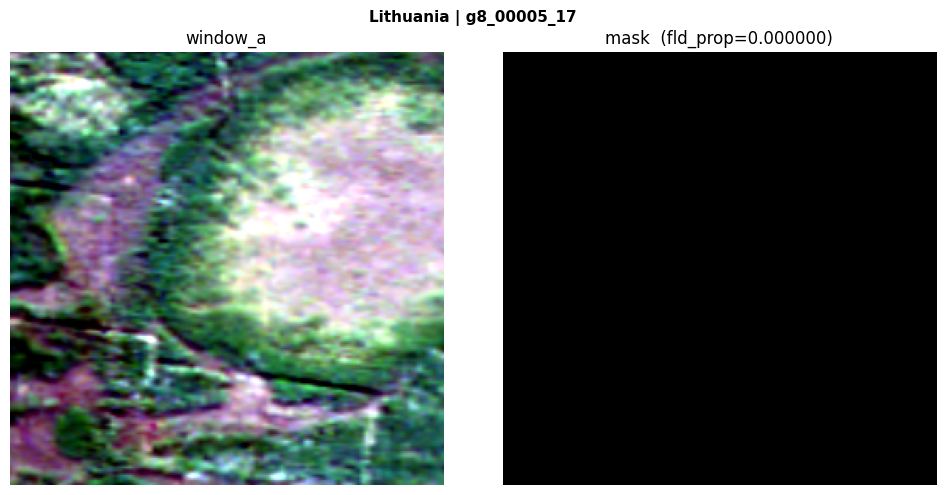

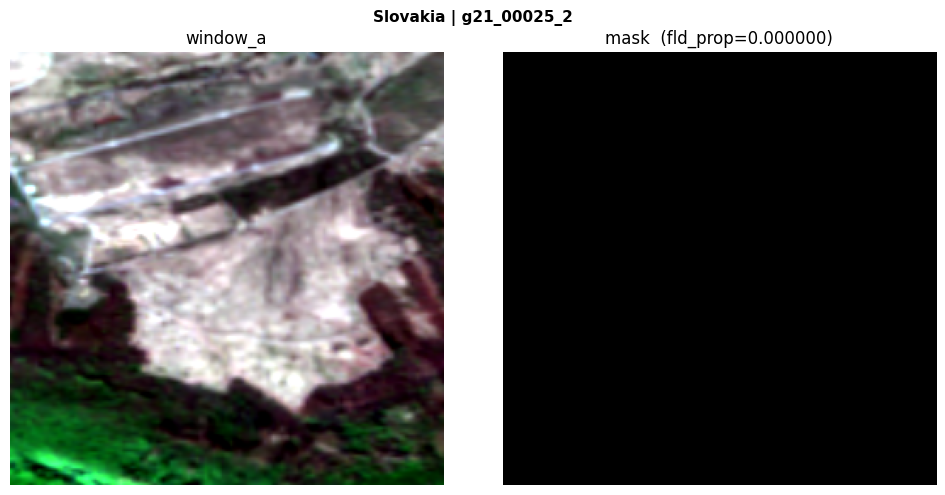

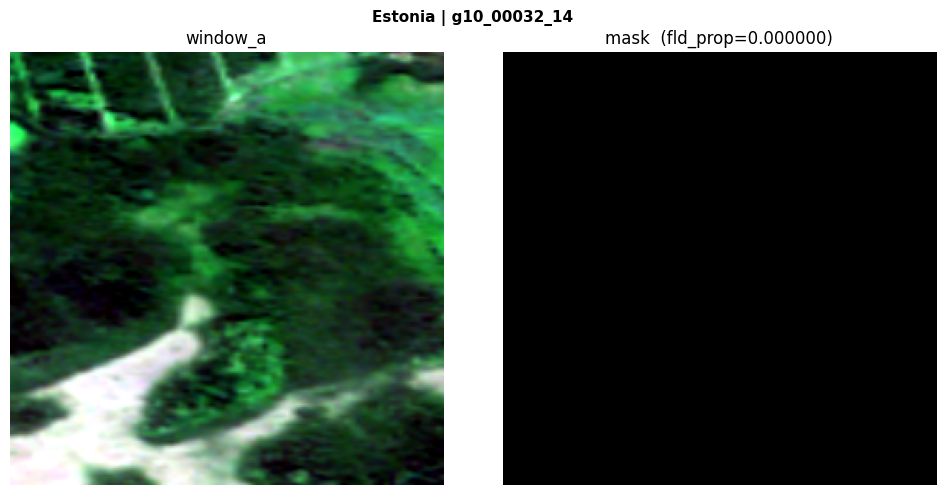

In [19]:
import numpy as np
import rasterio
from skimage.exposure import rescale_intensity

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR  = "/Users/LEstes/data/labels/cropland"  # root w/ relative paths
WINDOW    = "window_a"   # "window_a" or "window_b"
N_SAMPLES = 4            # number of dropped rows to inspect
RAND_SEED = 1

# ── Sample & plot ─────────────────────────────────────────────────────────────
# sample_rows = dropped_rows.sample(n=min(N_SAMPLES, len(dropped_rows)), 
#                                   random_state=RAND_SEED)
sample_rows = (in_boundary
 .query("fld_prop==0")
 .sample(n=4, random_state=RAND_SEED))

for _, row in sample_rows.iterrows():
    img_path  = Path(DATA_DIR) / row[WINDOW]
    mask_path = Path(DATA_DIR) / row["mask"]

    with rasterio.open(img_path) as src:
        img = src.read([1, 2, 3]).astype(np.float32)  # bands 1-3 as RGB proxy

    with rasterio.open(mask_path) as src:
        mask_arr = src.read(1)

    # Per-channel 2–98 percentile stretch for display
    img_disp = np.stack(
        [rescale_intensity(img[i],
                           in_range=tuple(np.percentile(img[i], (2, 98))),
                           out_range=(0.0, 1.0))
         for i in range(3)],
        axis=0,
    ).transpose(1, 2, 0)
    img_disp = np.clip(img_disp, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_disp)
    axes[0].set_title(WINDOW)
    axes[0].axis("off")

    axes[1].imshow(mask_arr, vmin=0, vmax=2, cmap="gray")
    axes[1].set_title(f"mask  (fld_prop={row['fld_prop']:.6f})")
    axes[1].axis("off")

    fig.suptitle(
        f"{row['country'].title()} | {row['name']}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()